In [18]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import numpy as np
  
# fetch dataset 
statlog_german_credit_data = fetch_ucirepo(id=144) 
  
# data (as pandas dataframes) 
df = statlog_german_credit_data.data.features 
y = statlog_german_credit_data.data.targets 


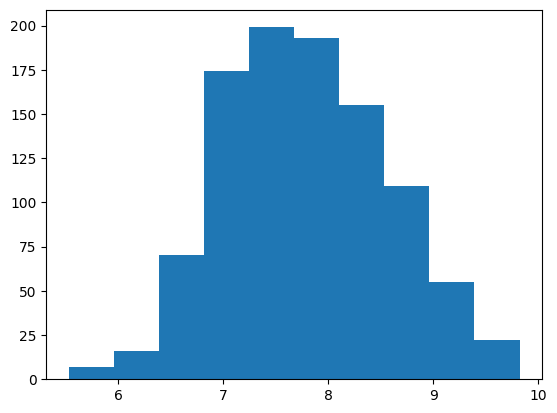

In [19]:
statlog_german_credit_data.variables

variables = ["status_account", "duration", "credit_history", "purpose", "obligo", 
             "savings", "employed_since", "installment", "marital_status", "debtors",
             "residence_since", "property", "age", "other_installment_plans", "housing", 
             "n_credits", "job", "people_liable", "telephone", "foreign_worker"]

df.columns = variables

df["target"] = y - 1 # convert 2s to 1s and 1s to 0s

categorical_cols = df.select_dtypes(include=['object']).columns

# 2. Convert those specific columns into one-hot encoded variables
# We use columns=categorical_cols so it leaves your numerical data untouched
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Feature Engineering 

#df_encoded["age_duration"] = df_encoded["age"] * df_encoded["duration"]
#df_encoded["obligo_age"] = df_encoded["obligo"] / df_encoded["age"] 
#df_encoded["payment_burden"] = df_encoded["obligo"] * df_encoded["duration"]
#df_encoded["total_payment"] = df_encoded["obligo"] * df_encoded["duration"]
df_encoded['obligo_log'] = np.log1p(df_encoded['obligo'])
df_encoded['duration_log'] = np.log1p(df_encoded['duration'])

import matplotlib.pyplot as plt
#plt.scatter(df_encoded["obligo"], df_encoded["duration"], c=df_encoded["target"])
plt.hist(df_encoded["obligo_log"])
plt.show()

## Logisitic Regression

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report 

train, test = train_test_split(df_encoded, test_size=0.3, random_state=42)
train_y = train.target
test_y = test.target

train_features = train.drop(columns=["target"])
test_features = test.drop(columns=["target"])

# Find out which boolean columns might significantly distinguish between good and bad credit
sig_cols = []

for col in train_features.columns: 
    if train[col].dtype == bool:

        # Create a cross-tabulation (contingency table)
        contingency_table = pd.crosstab(train["target"], train[col])

        chi2, p, dof, expected = chi2_contingency(contingency_table)
        if p < 0.05:
            print(f"{col}: P-value: {p:.5f}") # If p < 0.05, this model has predictive power
            sig_cols.append(col)
    
    else: 
        good_credit = train[train["target"]== 0][col].values
        bad_credit = train[train["target"]== 1][col].values

        stat, p_value = mannwhitneyu(good_credit, bad_credit)
        if p_value < 0.05:
            print(f"{col}: P-value: {p_value:.5f}") # If p < 0.05, this model has predictive power
            sig_cols.append(col)
        

#sig_cols.extend(train_features.select_dtypes(include=['int64']).columns)
print(sig_cols)

train_filtered = train_features[sig_cols].copy()
test_filtered = test_features[sig_cols].copy()

# Define which columns get which treatment
log_cols = ['obligo', 'duration']
numeric_cols = train_filtered.drop(columns=["obligo", "duration"]).select_dtypes(include=['int64', 'float32', 'float64']).columns

# Build a ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('log_transform', Pipeline([
        ('log',    FunctionTransformer(np.log1p)),
        ('scaler', StandardScaler())
    ]), log_cols),
    ('scale_only', StandardScaler(), numeric_cols),
], remainder='passthrough')  # passes categorical/binary cols through unchanged

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=500, class_weight="balanced", C = 1))
])

# Fit on train only — test never touches fit()
pipeline.fit(train_filtered, train_y)

# Transform is applied automatically when predicting
y_pred = pipeline.predict(test_filtered)
score  = pipeline.score(test_filtered, test_y)

print(classification_report(y_true=test_y, y_pred=y_pred))

duration: P-value: 0.00000
obligo: P-value: 0.01215
age: P-value: 0.00004
status_account_A12: P-value: 0.00219
status_account_A14: P-value: 0.00000
credit_history_A31: P-value: 0.00134
credit_history_A32: P-value: 0.04910
credit_history_A34: P-value: 0.00000
purpose_A41: P-value: 0.02498
purpose_A43: P-value: 0.00061
purpose_A46: P-value: 0.02380
savings_A63: P-value: 0.03109
savings_A64: P-value: 0.02415
savings_A65: P-value: 0.03288
employed_since_A72: P-value: 0.02837
employed_since_A75: P-value: 0.02502
marital_status_A92: P-value: 0.01899
marital_status_A93: P-value: 0.02556
property_A124: P-value: 0.00036
other_installment_plans_A143: P-value: 0.02816
housing_A152: P-value: 0.00009
housing_A153: P-value: 0.00411
obligo_log: P-value: 0.01215
duration_log: P-value: 0.00000
['duration', 'obligo', 'age', 'status_account_A12', 'status_account_A14', 'credit_history_A31', 'credit_history_A32', 'credit_history_A34', 'purpose_A41', 'purpose_A43', 'purpose_A46', 'savings_A63', 'savings_A64

C=0.001    AUC=0.6792
C=0.01     AUC=0.7422
C=0.1      AUC=0.7877
C=1        AUC=0.7980
C=10       AUC=0.7979
C=100      AUC=0.7980


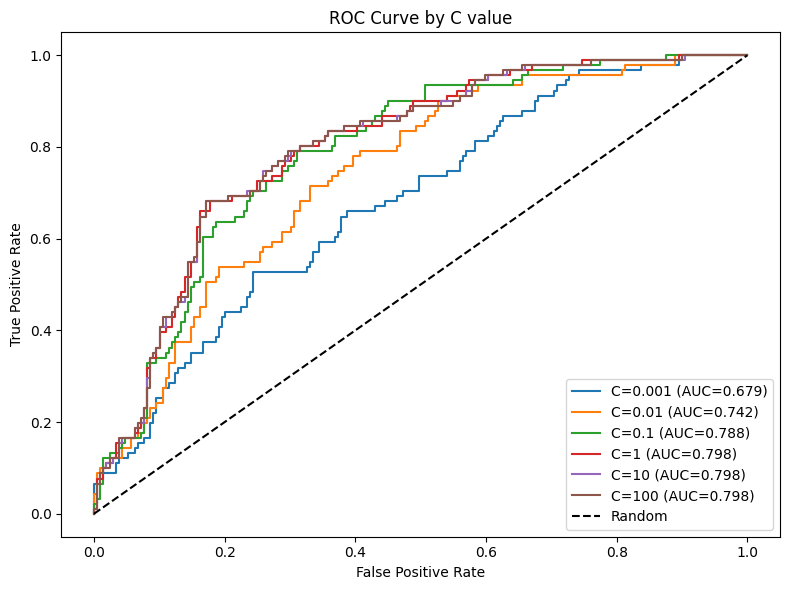

In [28]:
from sklearn.metrics import roc_auc_score, roc_curve

C_values = [0.001, 0.01, 0.1, 1, 10, 100]
results = {}

for C in C_values:
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=500, class_weight="balanced", C=C))
    ])
    pipe.fit(train_filtered, train_y)
    y_proba = pipe.predict_proba(test_filtered)[:, 1]
    auc = roc_auc_score(test_y, y_proba)
    results[C] = {'auc': auc, 'proba': y_proba}
    print(f"C={C:<8} AUC={auc:.4f}")

# Plot ROC curves for all C values
plt.figure(figsize=(8, 6))
for C, res in results.items():
    fpr, tpr, _ = roc_curve(test_y, res['proba'])
    plt.plot(fpr, tpr, label=f"C={C} (AUC={res['auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve by C value')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Next steps
- Feature Engineering (age, duration, obligo) CHECK
- regularization CHECK 
- checking multicollinearity 

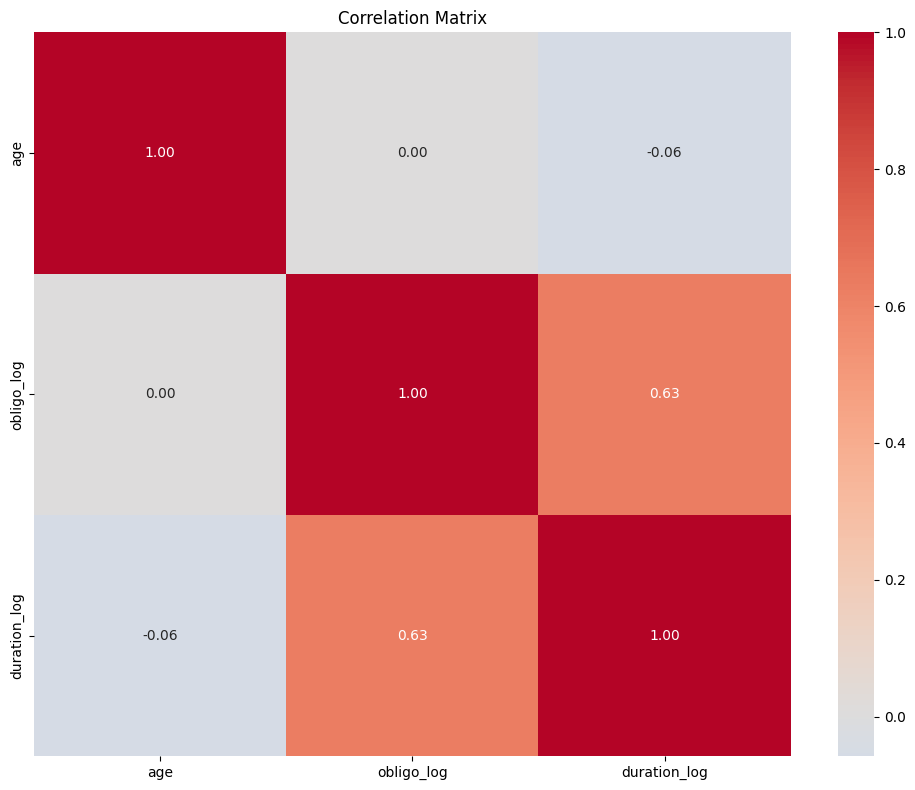

In [29]:
import seaborn as sns

corr = train_filtered[numeric_cols].select_dtypes(include=['int64', 'float32', 'float64']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [30]:
from sklearn.metrics import roc_auc_score

for col in numeric_cols:
    auc = roc_auc_score(train_y, train_filtered[col])
    print(f"{col}: {auc:.4f}")

age: 0.4024
obligo_log: 0.5598
duration_log: 0.6174


In [31]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

numeric_train = train_filtered[numeric_cols].select_dtypes(include=['int64', 'float32', 'float64'])

vif_df = pd.DataFrame({
    'feature': numeric_train.columns,
    'VIF': [variance_inflation_factor(numeric_train.values, i) 
            for i in range(numeric_train.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_df)

        feature        VIF
1    obligo_log  66.071061
2  duration_log  52.651359
0           age  10.093382


# Random Forest

### Next Steps: 
- Eigene Implementation einrichten
- am credit data set ausprobieren, mit sklearn vergleichen